In [31]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy
import PIL
import requests

In [32]:
np.random.seed(613)
x = np.arange(50)
y = np.random.randint(0, 100,50)

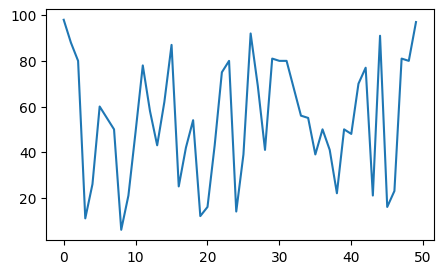

In [33]:
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(x,y)

<BarContainer object of 50 artists>

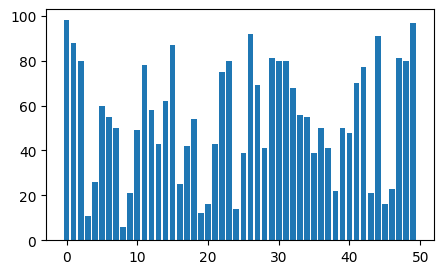

In [5]:
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(x,y)

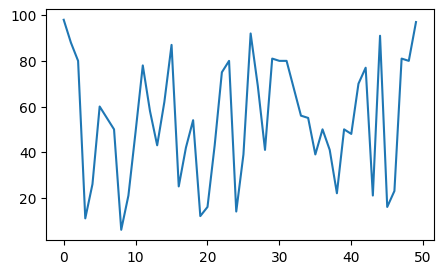

In [6]:
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(x,y)

(array([4., 6., 2., 5., 7., 6., 4., 3., 9., 4.]),
 array([ 6. , 15.2, 24.4, 33.6, 42.8, 52. , 61.2, 70.4, 79.6, 88.8, 98. ]),
 <BarContainer object of 10 artists>)

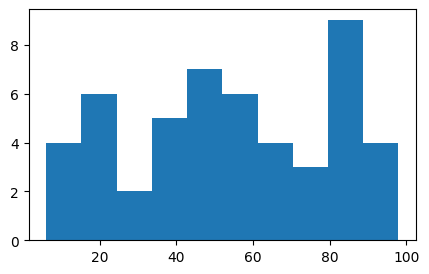

In [7]:
fig, ax = plt.subplots(figsize=(5, 3))
ax.hist(y)

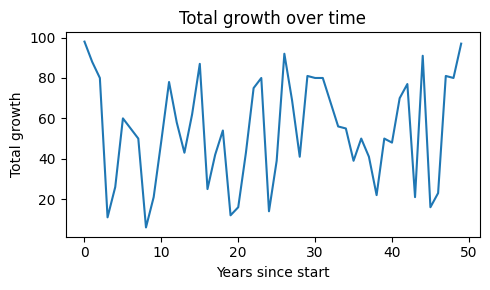

In [14]:
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(x,y)
ax.set_title('Total growth over time')
ax.set_ylabel('Total growth')
ax.set_xlabel('Years since start')
fig.tight_layout()

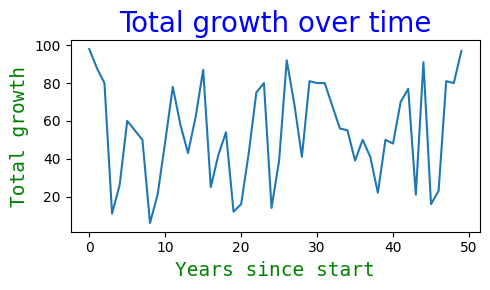

In [12]:
font1 = {'family':'sans-serif','color':'blue','size':20}
font2 = {'family':'monospace','color':'green','size':14}

fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(x,y)
ax.set_title('Total growth over time', fontdict=font1)
ax.set_ylabel('Total growth', fontdict=font2)
ax.set_xlabel('Years since start', fontdict=font2)
fig.tight_layout()

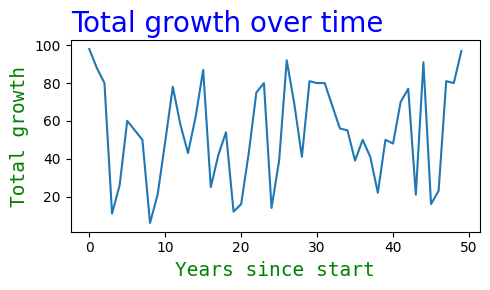

In [13]:
font1 = {'family':'sans-serif','color':'blue','size':20}
font2 = {'family':'monospace','color':'green','size':14}

fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(x,y)
ax.set_title('Total growth over time', fontdict=font1, loc='left')
ax.set_ylabel('Total growth', fontdict=font2)
ax.set_xlabel('Years since start', fontdict=font2)
fig.tight_layout()

/var/folders/7c/qn9b0xj13bgc7yl_nnwvpp9c0000gn/T/ipykernel_18042/430778414.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


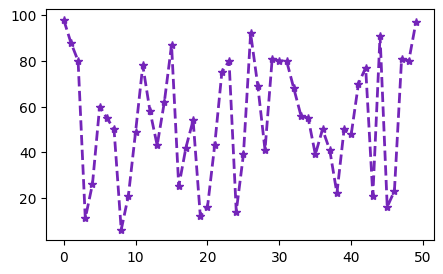

In [34]:
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(x,y,marker='*', color = '#7425b9', linestyle = '--', linewidth = 2)
fig.show()

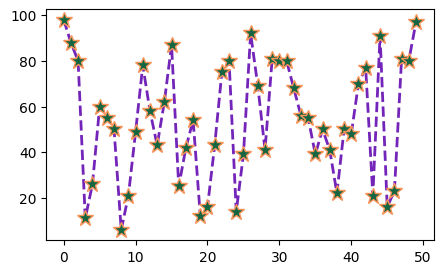

In [52]:
fig, ax = plt.subplots(figsize=(5,3))
ax.plot(x,y,marker='*',
    markersize = 12,
    color = '#7425b9',
    linestyle = '--',
    linewidth = 2,
    markeredgecolor = '#fa9359', 
    markerfacecolor = "#166741") 

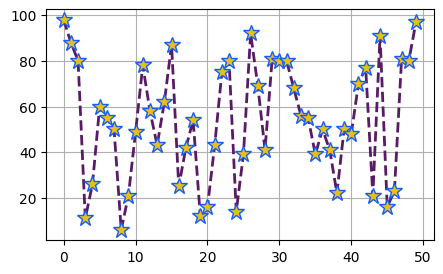

In [54]:
#Challenge -  modification 1
fig, ax = plt.subplots(figsize=(5,3))
ax.plot(x,y,marker='*',
    markersize = 12,
    color = "#591B65",
    linestyle = '--',
    linewidth = 2,
    markeredgecolor = '#155dfc', 
    markerfacecolor = "#e6c018")
ax.grid(axis='y')
ax.grid(axis='x')



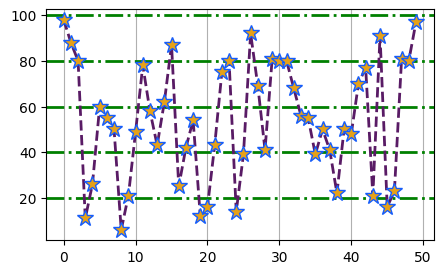

In [58]:
#Challenge -  modification 2
fig, ax = plt.subplots(figsize=(5,3))
ax.plot(x,y,marker='*',
    markersize = 12,
    color = "#591B65",
    linestyle = '--',
    linewidth = 2,
    markeredgecolor = '#155dfc', 
    markerfacecolor = "#e6a118")
ax.grid(axis='y', color ="green", linewidth = 2, linestyle = '-.')
ax.grid(axis='x')

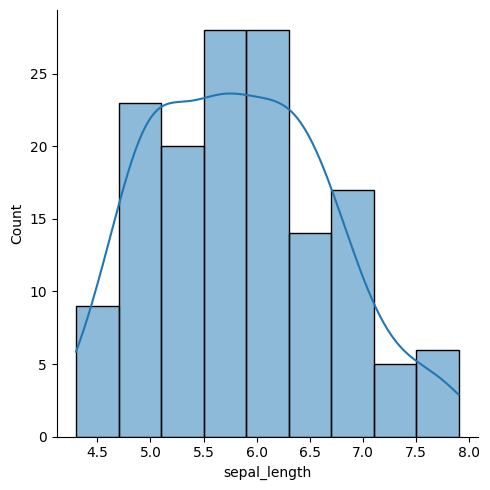

In [ ]:
#Visualizatio practice
# import seaborn as sns
df = sns.load_dataset('iris')

sns.displot( data=df["sepal_length"], kde=True )

In [4]:
# getting necessary libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})

# getting the data
temp = pd.read_csv('https://raw.githubusercontent.com/plotly/datasets/master/2016-weather-data-seattle.csv') # we retrieve the data from plotly's GitHub repository
temp['month'] = pd.to_datetime(temp['Date']).dt.month # we store the month in a separate column

# we define a dictionnary with months that we'll use later
month_dict = {1: 'january',
              2: 'february',
              3: 'march',
              4: 'april',
              5: 'may',
              6: 'june',
              7: 'july',
              8: 'august',
              9: 'september',
              10: 'october',
              11: 'november',
              12: 'december'}

# we create a 'month' column
temp['month'] = temp['month'].map(month_dict)

# we generate a pd.Serie with the mean temperature for each month (used later for colors in the FacetGrid plot), and we create a new column in temp dataframe
month_mean_serie = temp.groupby('month')['Mean_TemperatureC'].mean()
temp['mean_month'] = temp['month'].map(month_mean_serie)

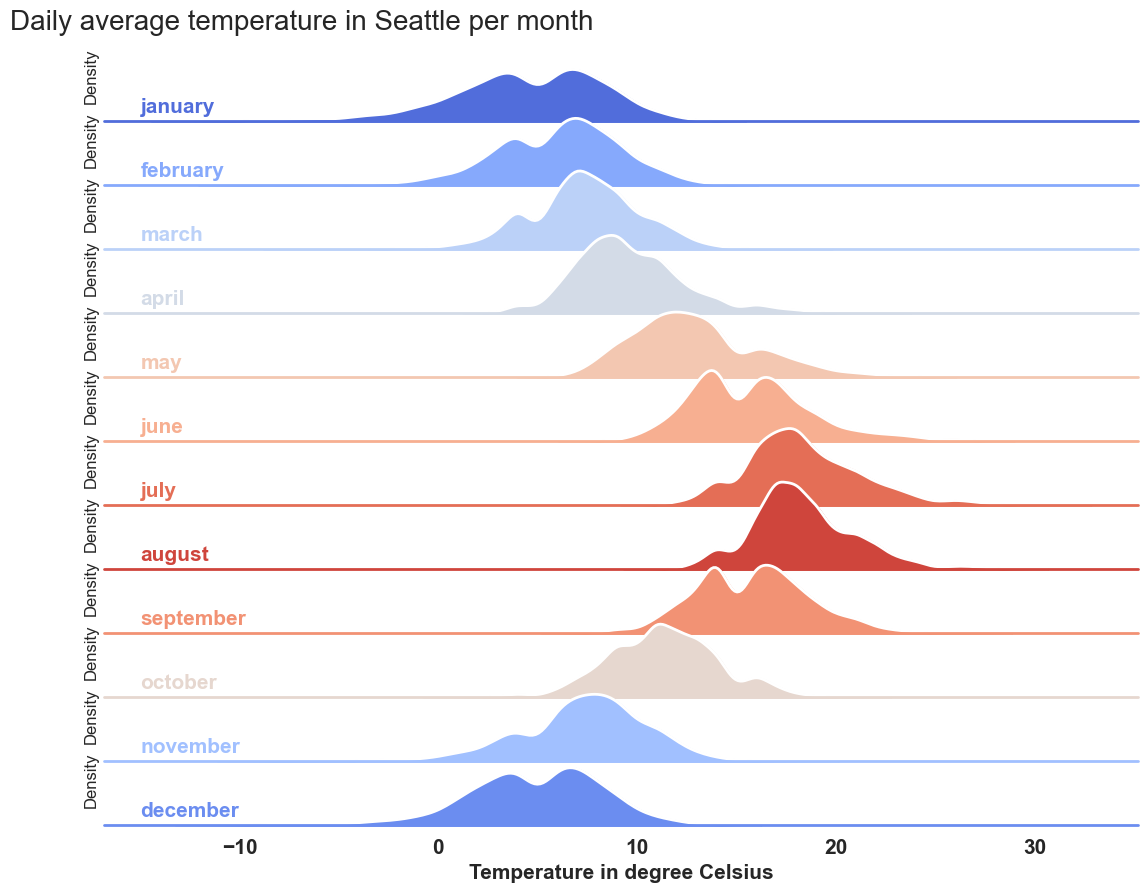

In [5]:
# we generate a color palette with Seaborn.color_palette()
pal = sns.color_palette(palette='coolwarm', n_colors=12)

# in the sns.FacetGrid class, the 'hue' argument is the one that is the one that will be represented by colors with 'palette'
g = sns.FacetGrid(temp, row='month', hue='mean_month', aspect=15, height=0.75, palette=pal)

# then we add the densities kdeplots for each month
g.map(sns.kdeplot, 'Mean_TemperatureC',
      bw_adjust=1, clip_on=False,
      fill=True, alpha=1, linewidth=1.5)

# here we add a white line that represents the contour of each kdeplot
g.map(sns.kdeplot, 'Mean_TemperatureC', 
      bw_adjust=1, clip_on=False, 
      color="w", lw=2)

# here we add a horizontal line for each plot
g.map(plt.axhline, y=0,
      lw=2, clip_on=False)

# we loop over the FacetGrid figure axes (g.axes.flat) and add the month as text with the right color
# notice how ax.lines[-1].get_color() enables you to access the last line's color in each matplotlib.Axes
for i, ax in enumerate(g.axes.flat):
    ax.text(-15, 0.02, month_dict[i+1],
            fontweight='bold', fontsize=15,
            color=ax.lines[-1].get_color())
    
# we use matplotlib.Figure.subplots_adjust() function to get the subplots to overlap
g.fig.subplots_adjust(hspace=-0.3)

# eventually we remove axes titles, yticks and spines
g.set_titles("")
g.set(yticks=[])
g.despine(bottom=True, left=True)

plt.setp(ax.get_xticklabels(), fontsize=15, fontweight='bold')
plt.xlabel('Temperature in degree Celsius', fontweight='bold', fontsize=15)
g.fig.suptitle('Daily average temperature in Seattle per month',
               ha='right',
               fontsize=20,
               fontweight=20)

plt.show()